## Question 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mandelbrot import mandelbrot

In [2]:
# Creating a grid of complex numbers
x = np.linspace(-2, 2, 1000)
y = np.linspace(-2, 2, 1000)
X, Y = np.meshgrid(x, y)
C = X + 1j*Y   #j is used for complex numbers in python as said in lecture.

In [3]:
# Run the iteration
result = mandelbrot(C)

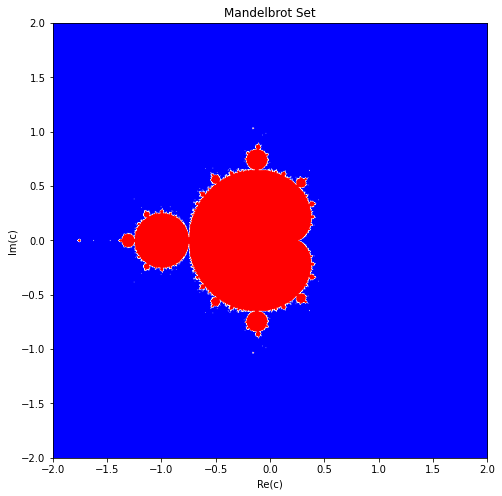

In [11]:
# Plot 1: bounded vs diverged
plt.figure(figsize=(8,8))
plt.imshow(result == 100, extent=[-2,2,-2,2], cmap='bwr')
plt.title('Mandelbrot Set')
plt.xlabel('Re(c)')
plt.ylabel('Im(c)')
plt.show()

Note: 
result == 100 means the point never diverged in 100 iterations -> these are the bounded points -> shown as True (1)
result < 100 means the point diverged at some iteration -> these are the diverged points -> shown as False (0)
So, the red ones are bounded
and the blue ones are the points that would diverge (go off to infinity)

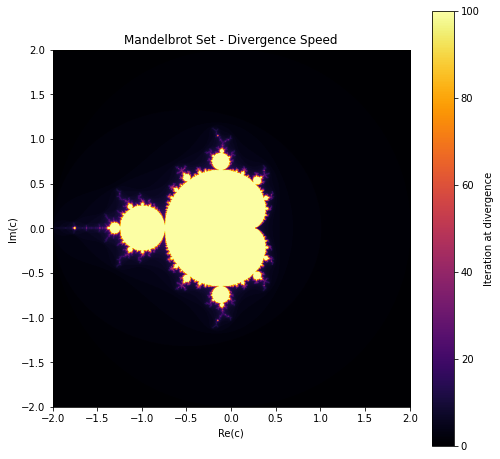

In [5]:
# Plot 2: colored by divergence iteration
plt.figure(figsize=(8,8))
plt.imshow(result, extent=[-2,2,-2,2], cmap='inferno', origin='lower')
plt.colorbar(label='Iteration at divergence')
plt.title('Mandelbrot Set - Divergence Speed')
plt.xlabel('Re(c)')
plt.ylabel('Im(c)')
plt.show()

The picture above shows the colourscale that indicates the iteration number at which the given point diverged.

## Question 2

In [12]:
# Part 1

def lorentz_eqn(t, W, sigma, r, b):
    """
    Computes and Returns the derivatives of the lorentz system.
    
    Parameters:
    t: used for time. --- a positive float
    W: [X,Y,Z] amplitudes for fourier nodes-- a list
    sigma: Prandtl--a dimnesionless paramter---a float
    r: Rayleigh number--a dimnesionless parameter -- a float
    b: length scale--a dimensionless parameter -- a float
    
    Returns [dX/dt, dY/dt, dZ/dt]    
    """
    
    X, Y, Z = W #unpacking the coords
    #writing eqns as given in instructions
    
    dXdt = -sigma*(X-Y)
    dYdt = r*X - Y - X*Z
    dZdt = -b*Z + X*Y
    
    return [dXdt, dYdt, dZdt]


In [15]:
# Part 2

# using given parameter values in the question;
# I will use solve_ivp
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

sigma, r, b = 10., 28, 8./3.
W0 = [0., 1., 0.]
sol = solve_ivp(lorentz_eqn, [0, 60], W0, args=(sigma, r, b), 
                dense_output=True, max_step=0.01)
print (sol)

  message: 'The solver successfully reached the end of the integration interval.'
     nfev: 36014
     njev: 0
      nlu: 0
      sol: <scipy.integrate._ivp.common.OdeSolution object at 0x7f354d511f60>
   status: 0
  success: True
        t: array([0.00000000e+00, 9.99000994e-05, 1.09890109e-03, ...,
       5.99810889e+01, 5.99910889e+01, 6.00000000e+01])
 t_events: None
        y: array([[ 0.00000000e+00,  9.98452742e-04,  1.09234542e-02, ...,
        -4.91942488e+00, -5.27989551e+00, -5.62532949e+00],
       [ 1.00000000e+00,  9.99901502e-01,  9.99070028e-01, ...,
        -8.38440795e+00, -9.02648662e+00, -9.63313020e+00],
       [ 0.00000000e+00,  4.98741706e-08,  6.00405759e-06, ...,
         1.36618456e+01,  1.37403825e+01,  1.38656790e+01]])
 y_events: None


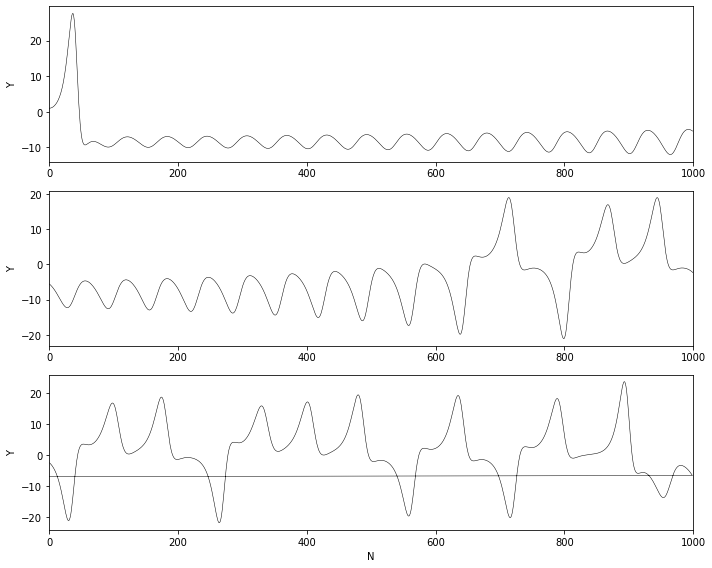

In [17]:
# Part 3

# Create time array and get solution
t = np.linspace(0, 30, 3000)
W = sol.sol(t)
Y = W[1]
N = t / 0.01  # N = t/dt where dt = 0.01

# Reproduce Figure 1 --- Y vs N in 3 rows as shown from the paper
fig, axes = plt.subplots(3, 1, figsize=(10, 8))

axes[0].plot(N[:1000] % 1000, Y[:1000], 'k', linewidth=0.5)
axes[0].set_ylabel('Y')
axes[0].set_xlim(0, 1000)

axes[1].plot(N[1000:2000] % 1000, Y[1000:2000], 'k', linewidth=0.5)
axes[1].set_ylabel('Y')
axes[1].set_xlim(0, 1000)

axes[2].plot(N[2000:3000] % 1000, Y[2000:3000], 'k', linewidth=0.5)
axes[2].set_ylabel('Y')
axes[2].set_xlim(0, 1000)
axes[2].set_xlabel('N')

plt.tight_layout()
plt.show()

the figure above closely matches Lorentz's figures in the journal.

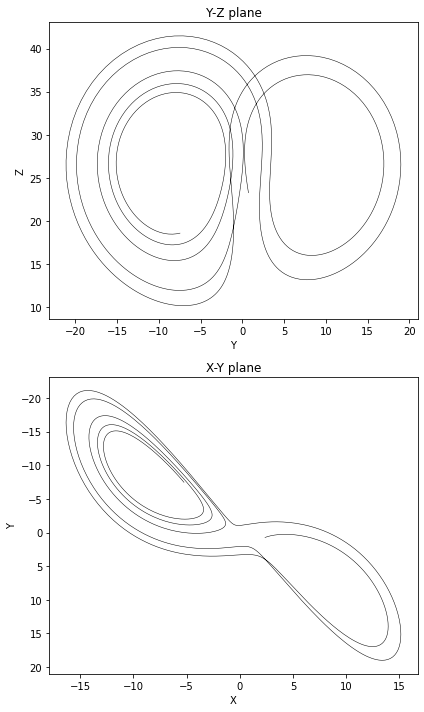

In [22]:
# Part 4

# Get solution at very fine time intervals between t=14 and t=19
t_fine = np.linspace(14, 19, 1000)
W_fine = sol.sol(t_fine)
X_fine = W_fine[0]
Y_fine = W_fine[1]
Z_fine = W_fine[2]

# Reproduce Figure 2
fig, axes = plt.subplots(2, 1, figsize=(6, 10))

# Top: Y vs Z
axes[0].plot(Y_fine, Z_fine, 'k', linewidth=0.5)
axes[0].set_xlabel('Y')
axes[0].set_ylabel('Z')
axes[0].set_title('Y-Z plane')

# Bottom: X vs Y
axes[1].plot(X_fine, Y_fine, 'k', linewidth=0.5)
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')
axes[1].set_title('X-Y plane')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

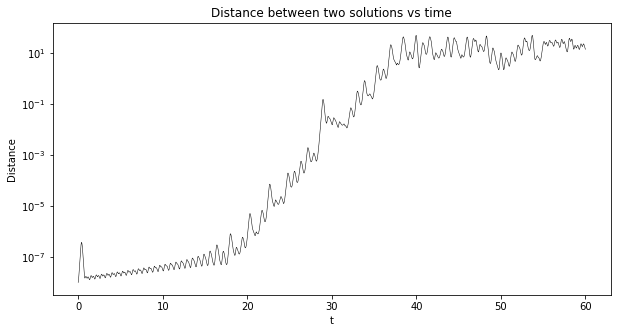

In [25]:
# Part 5

# Solve with slightly different initial conditions
W0_prime = [0., 1. + 1e-8, 0.]

sol2 = solve_ivp(lorentz_eqn, [0, 60], W0_prime, args=(sigma, r, b),
                 dense_output=True, max_step=0.01)

# Calculate distance between the two solutions
t_range = np.linspace(0, 60, 6000)
W1 = sol.sol(t_range)
W2 = sol2.sol(t_range)

distance = np.sqrt((W1[0]-W2[0])**2 + (W1[1]-W2[1])**2 + (W1[2]-W2[2])**2)

# Semilog plot
plt.figure(figsize=(10, 5))
plt.semilogy(t_range, distance, 'k', linewidth=0.5)
plt.xlabel('t')
plt.ylabel('Distance')
plt.title('Distance between two solutions vs time')
plt.show()